# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Gina Chen, Mikael Murphy-Rendon

**ID**: cc2859, mm3446

> **Due Date**
>
> Thursday, 9/03/26, 9:00pm

## Overview

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/hw01`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [3]:
using Random # allows for random seed generation
using Plots # basic plotting: can also install and use other packages
using Graphs # for making graphs and networks
using GraphRecipes # basic graph generation
using LaTeXStrings # allows for LaTeX formatting in plots
using Distributions # sampling and fitting of probability distributions
using CSV # file I/O for CSV files
using DataFrames # data structure for tabular data

In [4]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 50 Points)

### Problem 1 (10)

***Systems Modeling***:

Three factories are discharging a chemical called Chlororadiated
Ureadicarboxyl (or CRUD) into the Riley River. The river inflow has a
volume of 500,000 m$^3$/d and a CRUD concentration of 0.2 mg/L. The
river velocity is 25 km/d.

- Factory 1 discharges $100,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 10 mg/L;
- Factory 2 discharges $60,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 20 mg/L;
- Factory 3 discharges $200,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 8 mg/L.

CRUD decays in the river with a first order reaction rate
$k=0.45 \text{d}^{-1}$.

Environmental authorities have taken samples downriver of the three
factories and found that the CRUD concentration exceeds the regulatory
limit of 1 mg/L. CRUD can be removed at the source discharge at a cost
of $50E^2$ per $1000 \text{m}^3$ treated, where $E$ is the efficiency of
removal (the fraction of CRUD removed).

#### Problem 1.1 (2)

Draw a diagram of the river and factory system. Include definitions for
any notation you will use.
# Answer to Problem 1.1 
<div class="image-box">
    <img src='Answer to Problem 1.1.jpeg' alt="Diagram of the river and factory system">
</div>



#### Problem 1.2 (5)

Write down a set of conditions on the removal efficiencies $E_1$, $E_2$,
and $E_3$ (where the subscript corresponds to the factory where the
effluent is being treated) to guarantee compliance.

<div class="image-box">
    <img src='Answer to Problem 1.2 - pt1.jpeg' alt="Answer to Problem 1.2 - pt1">
   <img src='Answer to Problem 1.2 - pt2.jpeg' alt="Answer to Problem 1.2 - pt2">
    <img src='Answer to Problem 1.2 - pt3.jpeg' alt="Answer to Problem 1.2 - pt3">
</div>


#### Problem 2.3 (3)

Without finding an “optimal” solution, reason about which factories
ought to treat their effluent at a higher level than the others. This
can draw on considerations such as cost, the sequencing of discharges,
and the amount of CRUD discharged by each factory, or others.

**By considering the mass of CRUD discharged into the river by the three factories, Factory 3 should treat its effluent to a higher level than the other two. Factory 3 discharges the highest amount of CRUD at 1600 kg/d, compared to 1200 kg/d by Factory 2 and 1000 kg/d by Factory 1. This means that by looking at the mass of the containment being added to the river, Factory 3 needs to reduce the most. 
In addition, considering the downstream sequence of the factories, Factory 3 is located the furthest downstream, where the river last mixes with its treated effluent. Thus, the CRUD from Factory 3 has the shortest decay time between the mixing point and the location where environmental authorities sample the river's CRUD concentration. So, Factory 3 needs to treat its effluent further to compensate for the natural decay. 
This is also supported by the answers from Problem 1.2, where the E_3 has the largest coefficient in the inequality. This shows that increasing the removal efficiency of Factory 3 will have the greatest impact on the river meeting the regulatory limit.**


---
### Problem 2 (6)

***Systems Perturbations***:

Consider the perturbed phosphorous cycle example from Lecture 2. Now
suppose that the initial perturbation at $t=0$ is a 10% reduction in the
rate constant for the conversion of phosphorous from organic to
inorganic form (through an inhibition of phosphatase activity due to
e.g. acidic rain fall). When the new steady state is reached, how much
phosphorous will be in each compartment?

#### Answer 2

<u>Assumptions:</u> The system begins and ends at steady state; the flows between stocks are linear.<br>
<u>Variables:</u> $X_1$ - P in living biomass; $X_2$ - P in inorganic form; $X_3$ - P in dead organic matter; $\tau$-residence time.<br>
<u>Given:</u> Residence time of phosphorus (P) in living biomass is $\tau=4 days$ ; at $t=0$, 10% reduction in rate constant from conversion of $X_1$ & $X_3$ to $X_2$.<br>
&emsp;Steady state conditions: $\bar{X_1}=0.2μmol/L$; $\bar{X_2}=0.1μmol/L$; $\bar{X_3}=1.0μmol/L$
<br><br>
Equations:<br>
&emsp; Steady state equations:<br>
&emsp;&ensp; $X_1'$ + $X_2'$ + $X_3'$ = $X_1$ + $X_2$ + $X_3$

&emsp;System flow:<br>
&emsp;(1) $0.9\gamma*X_1=0.9\alpha*X_3$<br>
&emsp;(2) $0.9\alpha*X_3=\beta*X_1*X_2$<br>
&emsp;(3) $\beta*X_1*X_2=0.9\gamma*X_1$<br>
&emsp;(4) $\tau=\frac{mass}{flow}$<br>

Solve:<br>
(1) $0.9\gamma*X_1=0.9\alpha*X_3$ => $\frac{0.9\gamma}{0.9\alpha}=\frac{X_3}{X_1}=\frac{1.0μmol/L}{0.2μmol/L}$ => $\gamma=5\alpha$<br>
(3) $\beta*X_1*X_2=0.9\gamma*X_1$ => $\frac{0.9\gamma}{\beta}=X_2=0.1μmol/L$ => $\beta=9\gamma$ <br>
(4) $\tau=\frac{mass}{flow}$ => $4=\frac{X_1}{\gamma X_1}$ => $\gamma=0.25 days$<br>
(2) & (4) $\beta=9\gamma$ & $\gamma=0.25 days$ => $\beta=2.25$ <br>

$X_2 = X_2'$ from redundant equation (3)<br>
$X_1'$ + $X_2'$ + $X_3'$ = $X_1$ + $X_2$ + $X_3$<br>
$X_1'$ + 0.1μmol/L + $X_3'$ = $0.2μmol/L + 0.1μmol/L + 1.0μmol/L$ = $1.3μmol/L$<br>
$X_1'$ + $X_3'$ = $1.2μmol/L$<br>
$X_1' + \frac{\gamma}{\alpha}X_1'$ = $1.2μmol/L$<br>
$X_1' + 9X_1'$ = $1.2μmol/L$<br>
$10X_1'$ = $1.2μmol/L$<br>
> $X_1'$ = $.12μmol/L$<br>
> $X_2'$ = $.1μmol/L$<br>
> $X_3'$ = $.98μmol/L$<br>

!!!Missing interpretation
---
### Problem 3 (9)

***Debugging Code***:

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 3.1 (3)

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [5]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1] #Originally in the problem, it was given as min_value = 0, which is incorrect since 0 can be smaller than any input array values/elements
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

array_values_2 = [-10, -99, 0, 8, 108, 150]
@show minimum(array_values_2);

minimum(array_values) = 78
minimum(array_values_2) = -99


What is the logical flaw in the code? Fix it (describe what you changed
rather than reproducing the entire code snippet) and show that your
fixed code solves the problem.

### Answer to Problem 3.1

**The logical flaw appears at the original line of min_value = 0, because it is possible that all the values in the input array are greater than 0. This would result in the return minimum value being 0, which is not an element in the input array at all, as seen in this example array. In other words, minimum value can not be initialize to be 0 because 0 can be smaller than all elements in the input array, resulting in incorrect ouput from the program (giving 0, instead of the smallest value from the array as the answer). Therefore, I changed that line of code from min_value = 0 to **<i>min_value = array[1]</i>**. After making this change, the new output of running the previous cell becomes minimum(array_values) = 78, which is correct since 78 is the smallest value in the given exmaple array_values. To double check this result, I added in another example array_values with array_values_2 = [-10, -99, 0, 8, 108, 150], where there are negative numbers and zero, and the program still runs to give the correct answer -99. This is shown with the output of minimum(array_values_2) = -99, as -99 is the minimum (most negative value) of this array.** 

*Initially, after getting a "BoundsError: attempt to access 10-element Vector{Int64} at index [0]" of attempting to set the initial minimum value to be array[0]. I searched up for reference using "julia syntax does indexing start with 0 or what". In the Julia documentations (.), it states that "Julia's arrays are indexed starting at 1", therefore I set the initial minimum value to be arrahttps://docs.julialang.org/en/v1/devdocs/offset-arrays/#:~:text=Conventionally%2C%20Julia's%20arrays%20are%20indexed,to%20specify%20arbitrary%20starting%20indicesy[1] to be valid.*

#### Problem 3.2 (3)

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [6]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials) # This line was originally outcomes = zero(n_trials) 
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.382


What does this `MethodError` mean? Why does this code produce one? Fix
the error (describe what you changed rather than reproducing the entire
code snippet) and solve the problem.

### Answer to Problem 3.2 

**In short, this `MethodError`  means that there is some wrong argument type being passed into an array operating function, which is cuased by defining the array "outcomes" incorrectly in line outcomes = zero(n_trials). This can be fixed by replacing that line with outcomes = zeros(n_trials).**

**The explainations are as follows. The complete error message of running the original code is "MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64) The function `setindex!` exists, but no method is defined for this combination of argument types.", so I searched on Google for "what does the error mean in julia MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64)" and the AI Overview response indicates that this is because "...trying to modify an element inside a single integer (Int64) as if it were a collection (like an array)". Reading through the code, I found out that two places invovle working with array, outcomes = zero(n_trials) and outcomes[i] = (sum(passadieci()) > 11). From my understanding from Python, the line outcomes = zero(n_trials) is meant to create the "outcomes" array with length of n_trials and all entry being zeros. On the other hand, outcomes[i] = (sum(passadieci()) > 11) is used to assign values into the entries in the array "outcomes". By looking up the function zero(x), I found that zero(x) returns the additive identity element (the zero value) for the type or instance of x, such as returning 0 or 0.0 (https://www.jlhub.com/julia/manual/en/function/zero). Therefore, I searched for how to create an array of zeros in Julia, which is a very similiar function of <i>zeros()</i> (https://www.jlhub.com/julia/manual/en/function/zeros). By changing the line from outcomes = zero(n_trials) to <i>outcomes = zeros(n_trials)</i>, the program no longer produces a MethodError but win_prob = 0.382. Moving forward, we know that the zeros(A) function is what we should use to create an array or matrix with all entry being zero, in julia.** 

**Also, the expected payout of the passadeici game is some probability between 0.3 to 0.5. This is because when running the trial for multiple times, the win_prob can be some values ranging from 0.361 to 0.404. Thus, I assume any probability greater than 0.3 and under 0.5 is reasonable.**


#### Problem 3.3 (3)

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [7]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m # This line was originally return vect - m 

end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
 -0.2530763598508532
 -0.3987461186978969
 -0.4051668577883766
  ⋮
  0.4389503908252199
 -0.2337089015832472
  0.13250675888374663
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

What does this `MethodError` mean? Why does this code produce one? Fix
the error (describe what you changed rather than reproducing the entire
code snippet) and solve the problem.


### Answer to Problem 3.3
**In short, this MethodError means that there is an error between operation of a vector and scalar. This exists because Julia cannot handle element-wise subtraction between a vector and scalar by only using a subtraction sign. The fix is to use a dot syntax (array .- scalar) to support broadcasting.**

**The complete error message from the original code was "MethodError: no method matching -(::Vector{Float64}, ::Float64) For element-wise subtraction, use broadcasting with dot syntax: array .- scalar The function `-` exists, but no method is defined for this combination of argument types." This provides sufficient information on error and the fix. Since element-wise subtraction is needed for the purpose of this problem of "removing the mean of the vector from <i>all</i> of its components", this error occurs at where the subtraction happens. Particularly, it's the subtraction of a scalar from a vector. I was able to easily fix the error by adding in a dot in front of the subtraction in the line <i>return vect - m</i>, turning it into <i>return vect .- m</i>, as this is the solution suggested in the error message. More rigorously, this MethodError is caused by subtracting a single number (a scalar) directly from an array (a vector)(https://stackoverflow.com/questions/77294942/julia-no-method-matching-float64-vectorfloat64) with incorrect syntax, which is what's originally done when subtracting m (a scalar because it's a value of the computed mean) from vect (a vector from the input) with only a subtraction symbol. This demonstrates that julia does not allow element wise operation with just operation symbol between a vector and a scalar, which is different from Python. According to AI Overview, this capability Python has is called broadcasting, where the smaller shape of the two (the scalar m in our problem) would be stretched to perform operation. (https://numpy.org/devdocs/user/basics.broadcasting.html) In julia, this capability can be used when we added in a dot syntax right before the subtraction sign, as the error message ealier suggested "use broadcasting with dot syntax: array .- scalar".**


### Problem 4 (5)

***Loading and Manipulating Data***

The file `fha.csv` contains data[1] on the size of American metro areas
and the number of miles people drive in each metro area each day. This
problem asks you to load and work with this data to get practice with
data manipulation in Julia.

#### Problem 4.1 (2)

Load `fha.csv` into a Julia `DataFrame`. How many rows and columns does
the data have?

In [8]:
fha_df = DataFrame(CSV.File("data/fha.csv")) # read in data file and convert to DataFrame

Row,metro_area,population,road_length (mi),land_area (sq mi),daily_vmt (mi/day)
,String,Int64,Int64,Int64,Int64
1,"New York--Newark, NY--NJ--CT",18351295,44249,3450,288778000
2,"Los Angeles--Long Beach--Anaheim, CA",12150996,24934,1736,245216000
3,"Chicago, IL--IN",8608208,30071,2443,166441000
4,"Miami, FL",5502379,15688,1239,142662000
5,"Philadelphia, PA--NJ--DE--MD",5441567,21196,1981,108775000
6,"Dallas--Fort Worth--Arlington, TX",5121892,24104,1779,154569000
7,"Houston, TX",4944332,20786,1660,142176000
8,"Washington, DC--VA--MD",4586770,13550,1322,104833000
9,"Atlanta, GA",4515419,25388,2645,159660000


Answer: The data has 492 rows and 5 columns.

#### Problem 4.2 (3)

Calculate the number of miles driven per person per day for every metro
area. Make a scatterplot of this on the $y$-axis and the population of
the city on the $x$-axis. Make sure to label your axes and include a
caption clearly describing the plot. Highlight where the New York City
and Houston metro areas are on the plot and make a legend clearly
labelling any plot features.

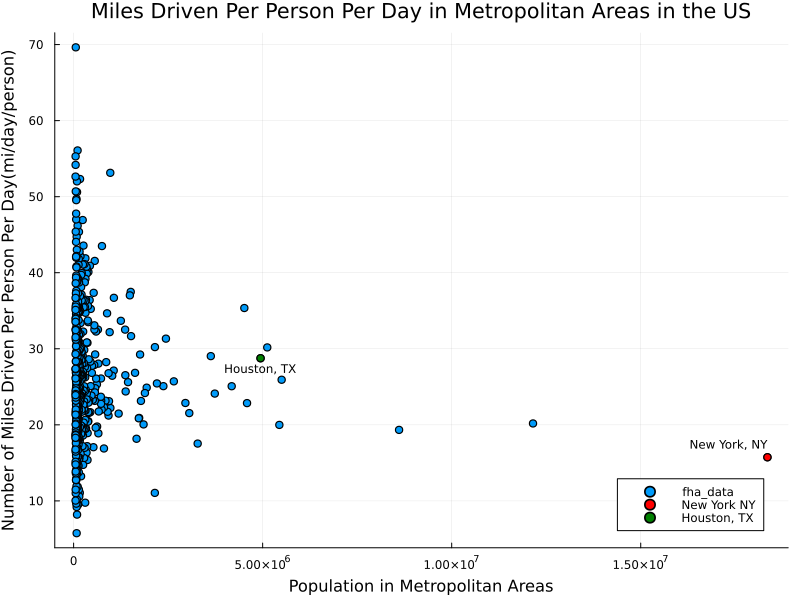

In [ ]:
# initialize empty arrays for metro area series
miles_arr = Float64[]
population_arr = Float64[]

#populate series with computed/pulled data from fha dataframe in previous code block
miles_arr = fha_df[!,"daily_vmt (mi/day)"]./fha_df[!,"population"]
population_arr = fha_df[!,"population"]

#plot primary data series as scatter plot 
scatter(population_arr,miles_arr, 
        size=(800,600),
        title="Miles Driven Per Person Per Day in Metropolitan Areas in the US", 
        grid=true,
        xlabel="Population in Metropolitan Areas",
        ylabel="Number of Miles Driven Per Person Per Day(mi/day/person)",
        labels="fha_data",
        leg=:bottomright
        )

#index fha df for NYC and Houston positions & overlay those points to original plot
ny_pos = findfirst(==("New York--Newark, NY--NJ--CT"),fha_df.metro_area)
houston_pos = findfirst(==("Houston, TX"),fha_df.metro_area)
scatter!([population_arr[ny_pos]],[miles_arr[ny_pos]], color = :red, labels="New York NY")
scatter!([population_arr[houston_pos]],[miles_arr[houston_pos]], color = :green, labels="Houston, TX")
#annotate plot with corresponding city labels
ann_ny=(population_arr[ny_pos],miles_arr[ny_pos],text("New York, NY\n\n",pointsize=8,halign=:right))
ann_houston=(population_arr[houston_pos],miles_arr[houston_pos],text("Houston, TX\n\n",pointsize=8,valign=:top))
annotate!([ann_ny, ann_houston])

### Problem 5 (20)

***Computational Modeling***:

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable. The flow of wastewater through this
treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>.

[1] From the [2023 Federal Highway Administration’s Highway Statistics
report](https://www.fhwa.dot.gov/policyinformation/statistics/2023/pdf/hm72.pdf)

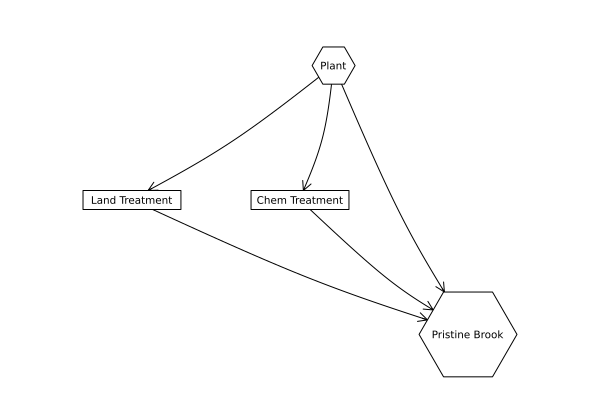

In [10]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 5.1 (2)

Make a figure showing notation for how YUK moves through the system for
a given treatment allocation. Make sure to define your variables. You
can make this by modifying the graph above or with an independent figure
included in your solution.

You can modify the edge labels (by editing the `edge_labels` dictionary
in the code) in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a> to show how
the wastewater allocations result in the final YUK discharge into
Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

#### Problem 5.2 (4)

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values.

> **None**
>
> You can find some basics on writing mathematical equations using the
> LaTeX typesetting syntax
> [here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
> and a cheatsheet with LaTeX commands can be found on the course
> website’s [Resources
> page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

#### Answer Problem 5.2:<br>
&emsp; Flow balance:<br>
&emsp; $X_1 + X_2 + X_3 = 100 \frac{m^3}{d}$<br>
&emsp; Mass balance:<br>
&emsp; $Q_{0}C_{0} = Q_{pl}C_{pl} + Q_{pc}C_{pc} + Q_{pb}C_{pb}$<br>
&emsp;&emsp; => $100\frac{kg}{d} = 0.2X_2 + (X_2 - 0.005X_2^2) + X_3$<br>
&emsp; Cost:<br>
&emsp; $cost_{total}=\frac{X^2}{20}\frac{\$}{d} + \frac{\$1.50}{m^3}X_2$

#### Problem 5.3 (3)

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [11]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [12]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


Make sure you comment your code appropriately to make it clear what is
going on and why.

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia).

Plot the results of these experiments by making a scatterplot of YUK
discharge into the lake vs. treatment cost. Make sure to label your axes
and include a legend, as well as a caption clearly describing the plot.

#### Problem 5.4 (3)

Do any satisfy the YUK effluent standard (plot this as well as a dashed
red line). What was the cost of solutions satisfying the standard?

#### Problem 5.5 (4)

What can you say about the tradeoff between treatment cost and YUK
discharge? You don’t have to find an “optimal” solution to this problem,
but what do you think would be needed to find a better solution?

#### Problem 5.6 (4)

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 4.3.
How do their values compare to the spread of values that you found in
that problem?

## References

List any external references consulted, including classmates.

- https://docs.julialang.org/en/v1/devdocs/offset-arrays/#:~:text=Conventionally%2C%20Julia's%20arrays%20are%20indexed,to%20specify%20arbitrary%20starting%20indices Julia documentations referenced for Problem 3.1 
- https://www.jlhub.com/julia/manual/en/function/zero and https://www.jlhub.com/julia/manual/en/function/zeros Reference for Problem 3.2 on the zero(x) and zeros(A) function 
- https://stackoverflow.com/questions/77294942/julia-no-method-matching-float64-vectorfloat64 and https://numpy.org/devdocs/user/basics.broadcasting.html are used as reference for explaination on element wise operation in julia and python, to answer Problem 3.3
- Used as reference for Julia plotting (problem 4.2): https://github.com/sswatson/cheatsheets/blob/master/plotsjl-cheatsheet.pdf
- Used as reference for array and loop syntax in Julia (problem 4.2): https://cheatsheet.juliadocs.org/
- Used as reference for csv reading syntax (problem 4.1): https://csv.juliadata.org/stable/reading.html 
- Used as reference for array indexing in dataframes (problem 4.2): https://discourse.julialang.org/t/how-to-find-the-first-instance-of-a-value-in-an-array/55290